# SIR Model Computer Practical
**Understanding Disease Dynamics**

## Learning Objectives
By the end of this practical, you will:
- Understand basic epidemiological modeling concepts
- Implement SIR and SIRD models in Python
- Analyze how parameters affect epidemic outcomes
- Create visualizations of epidemic data

## Instructions for Students
- 🟢 **Code**: Code provided - run and observe
- 🟡 **TODO**: You need to complete these - look for TODO comments
- 🔴 **Question**: Analysis questions you need to answer

**Estimated time: 1-2 hours**

In [2]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Background: SIR Model Basics

The **SIR model** divides population into three compartments:
- **S (Susceptible)**: Can catch the disease  
- **I (Infectious)**: Have disease and can transmit it
- **R (Recovered)**: Recovered and immune

**Mathematical equations:**
- dS/dt = -β × S × I / N
- dI/dt = β × S × I / N - γ × I  
- dR/dt = γ × I

**Key parameters:**
- **β (beta)**: Transmission rate
- **γ (gamma)**: Recovery rate  
- **R₀**: Basic reproduction number = β/γ

## **Exercise 1: Implement Basic SIR Model (20 minutes)**

**Step 1.1: Create the SIR equations**

Your task: Complete the SIR differential equations and create a simulation function.

In [3]:
# 🟡 SIR model function

def sir_model(y, t, beta, gamma):
    """
    SIR model differential equations

    Parameters:
    - y: [S, I, R] populations at time t
    - beta: transmission rate
    - gamma: recovery rate

    Returns:
    - [dS/dt, dI/dt, dR/dt]
    """
    S, I, R = y
    N = S + I + R  # Total population

    # SIR differential equations
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return dSdt, dIdt, dRdt

# Test your function
print("Testing SIR model function...")
test_result = sir_model([990, 10, 0], 0, 0.3, 0.1)
print(f"Result: {test_result}")
print("If you see three numbers, your function works!")


Testing SIR model function...
Result: (-2.97, 1.9700000000000002, 1.0)
If you see three numbers, your function works!


**Step 1.2: Create simulation and visualization function and run your first simulation**

Now that we have the SIR model equations working, let's create a function to simulate and visualize epidemic scenarios.

This function will:
1. **Set up initial conditions** - most people susceptible, few infectious, none recovered
2. **Solve the differential equations** over time using SciPy's numerical solver
3. **Create a plot** showing how S, I, R populations change over time
4. **Return the results** for further analysis

This is where we'll see our mathematical model come to life as epidemic curves!

Running SIR simulation with β=0.3, γ=0.1
R0 = 3.00


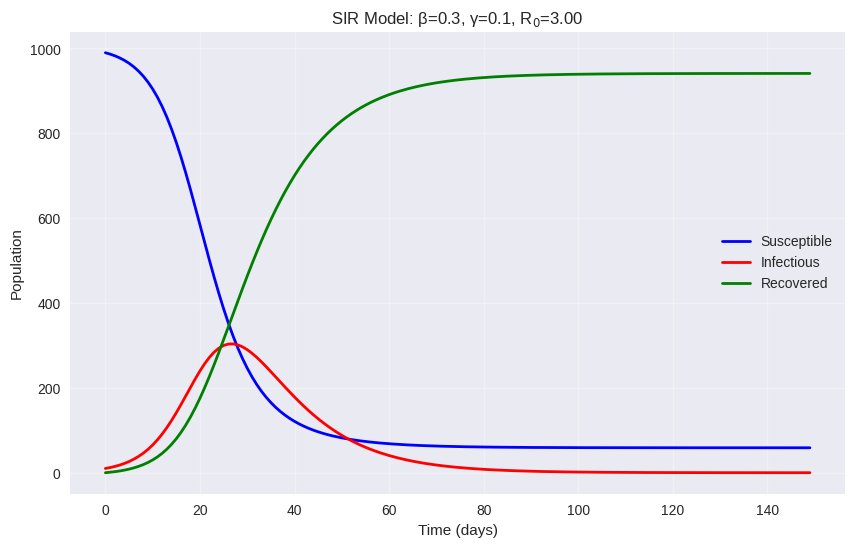

Peak infections: 304 on day 27
Final recovered: 941


In [4]:
# 🟡 Run SIR simulation and create plot

def run_sir_simulation(beta, gamma, N=1000, I0=10, days=150):
    # Initial conditions (provided)
    S0 = N - I0
    R0 = 0
    y0 = [S0, I0, R0]

    # Time points (provided)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # Solve differential equations (provided)
    sol = odeint(sir_model, y0, t, args=(beta, gamma))
    S, I, R = sol.T


    # TODO: Create the plot
    # Your task: Create a plot showing S, I, R over time - the example for S is given

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
    plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
    plt.plot(t, R, 'g-', label='Recovered', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title(f'SIR Model: β={beta}, γ={gamma}, R$_0$={beta/gamma:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R

##############################################
# Test your simulation function
##############################################
beta = 0.3
gamma = 0.1

print(f"Running SIR simulation with β={beta}, γ={gamma}")
print(f"R0 = {beta/gamma:.2f}")

t, S, I, R = run_sir_simulation(beta, gamma)

# Calculate and print key results
peak_infected = np.max(I)
peak_day = np.argmax(I)
final_recovered = R[-1]

print(f"Peak infections: {peak_infected:.0f} on day {peak_day}")
print(f"Final recovered: {final_recovered:.0f}")


### 🔴 **Analysis** Questions - TODO: Answer these questions

Try out different beta and gamma values and answer the following question:
*   **What does R₀ > 1 mean for the epidemic?**
    * it means that the infected people will infect others, making the population infected
    



---



## **Exercise 2: Parameter Exploration (25 minutes)**

Now we'll explore one of the most important aspects of epidemic modeling: **how transmission rate affects epidemic outcomes**.

**Step 2.1: Compare different transmission rates**

We'll systematically test different values of β (transmission rate) while keeping γ (recovery rate) constant. This will help us understand:
- How R₀ values translate to real epidemic behavior
- The relationship between transmission and epidemic severity
- Why small changes in β can have dramatic effects

The following function will run four different scenarios and create both **visual comparisons** and a **quantitative summary table** of key metrics. Go through the code and make sure you understand what happens and how to interpret the plots.

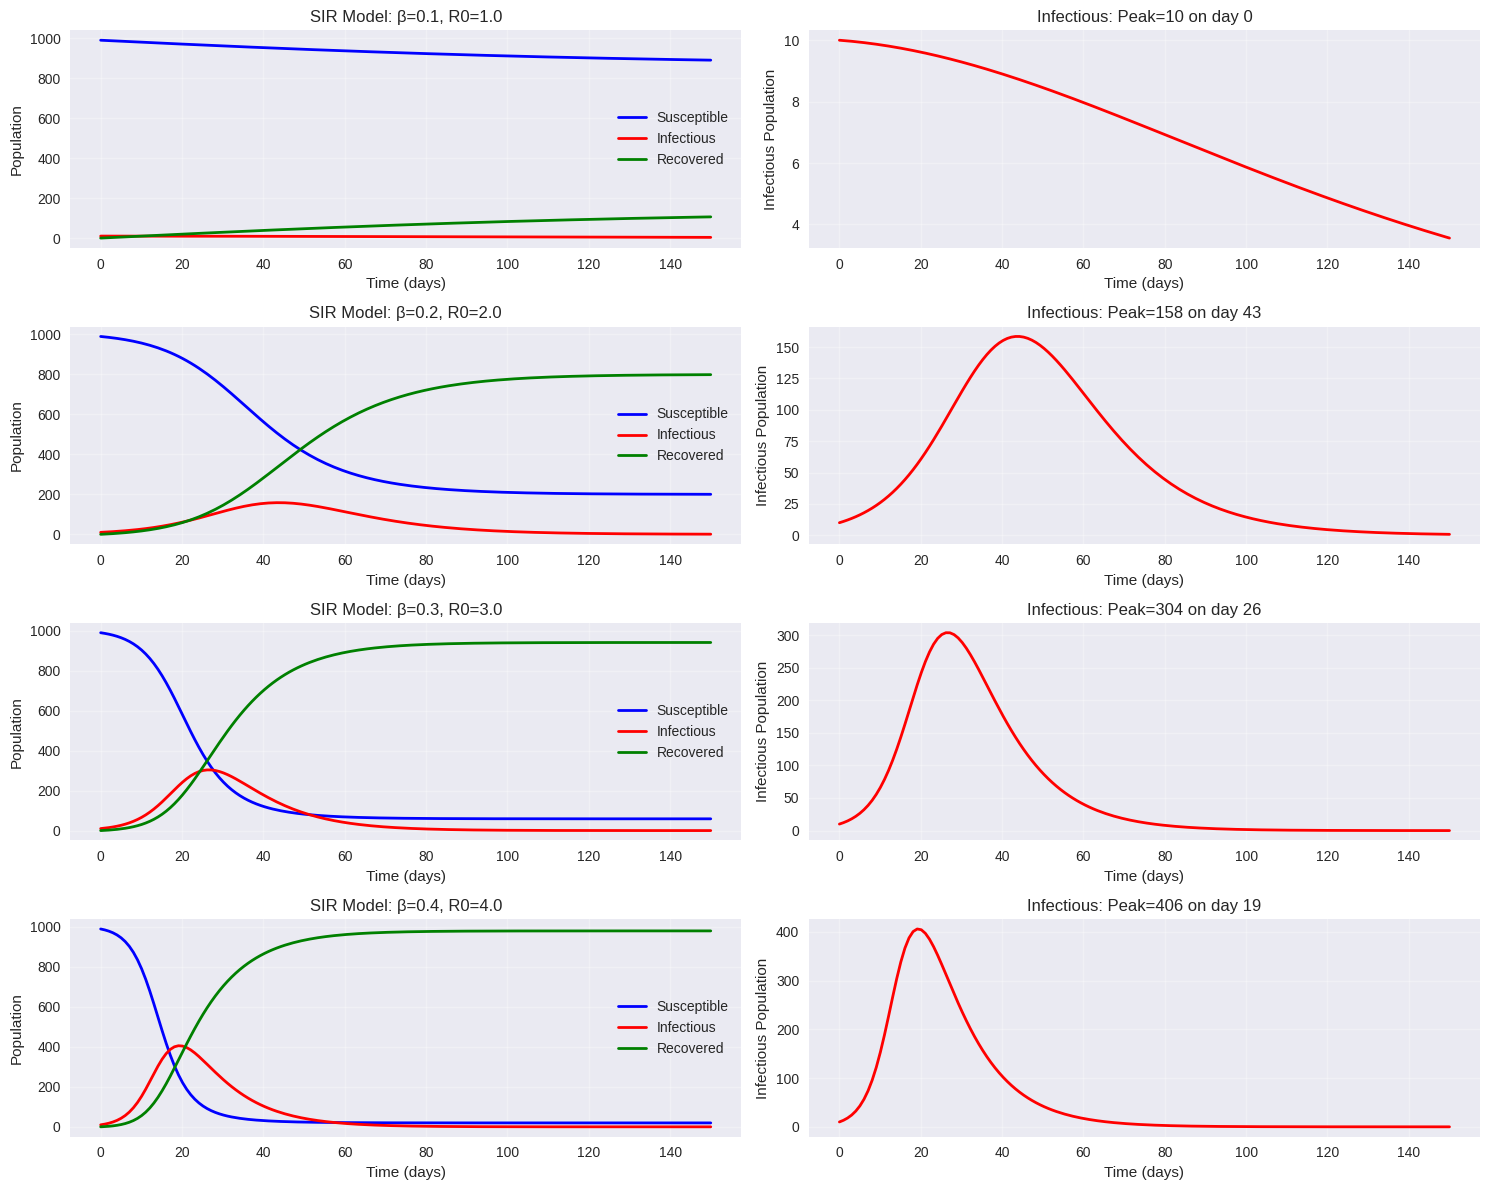

Parameter Analysis Results:
   beta   R0  peak_infected  peak_day  final_recovered
0   0.1  1.0           10.0         0            106.1
1   0.2  2.0          158.4        43            799.0
2   0.3  3.0          303.5        26            941.2
3   0.4  4.0          405.7        19            980.4


In [5]:
# 🟢 Compare different transmission rates
def compare_transmission_rates():
    beta_values = [0.1, 0.2, 0.3, 0.4]
    gamma = 0.1

    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    results = []

    for i, beta in enumerate(beta_values):
        # Run simulation without plotting (just get the data)
        S0, I0, R0 = 990, 10, 0
        t = np.linspace(0, 150, 150)
        sol = odeint(sir_model, [S0, I0, R0], t, args=(beta, gamma))
        S, I, R = sol.T

        # Calculate metrics
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        final_recovered = R[-1]
        R0 = beta / gamma

        results.append({
            'beta': beta,
            'R0': R0,
            'peak_infected': peak_infected,
            'peak_day': peak_day,
            'final_recovered': final_recovered
        })

        # Left subplot: Full SIR model
        axes[i, 0].plot(t, S, 'b-', label='Susceptible', linewidth=2)
        axes[i, 0].plot(t, I, 'r-', label='Infectious', linewidth=2)
        axes[i, 0].plot(t, R, 'g-', label='Recovered', linewidth=2)
        axes[i, 0].set_title(f'SIR Model: β={beta}, R0={R0:.1f}')
        axes[i, 0].set_xlabel('Time (days)')
        axes[i, 0].set_ylabel('Population')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)

        # Right subplot: Focus on infectious curve
        axes[i, 1].plot(t, I, 'r-', linewidth=2)
        axes[i, 1].set_title(f'Infectious: Peak={peak_infected:.0f} on day {peak_day}')
        axes[i, 1].set_xlabel('Time (days)')
        axes[i, 1].set_ylabel('Infectious Population')
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)
    print("Parameter Analysis Results:")
    print(results_df.round(1))

    return results_df

results = compare_transmission_rates()

**Step 2.2: Interpretation**

🔴 **Questions** - TODO: Answer these questions

Based on the parameter exploration above, answer the following questions:

1. **How does increasing β affect the epidemic peak?**
   - increasing β increases the peak. everytime the β is increased the peak increased shwing a clear correlation

2. **What happens to epidemic duration as β increases?**
   - the peak happens days earlier when the peak is increased, meaning that the people that outbreak happens earlier.

3. **Which β value represents the most dangerous scenario?**
   - β = 0.4 is the most dangerous as more people get infected.

4. **At what R₀ value does the epidemic become severe?**
   - when R₀ is greater than 1, more people get infected and get infected quicker.



---



## **Exercise 3: Add Death - SIRD Model (25 minutes)**

**Step 3.1: Implement SIRD model**

Real diseases don't just result in recovery - unfortunately, some infectious individuals die. The **SIRD model** extends our SIR framework by adding a fourth compartment: **D (Deceased)**.

**Key changes:**
- Infectious individuals can now follow **two pathways**: recover (rate γ) OR die (rate μ)
- We track cumulative deaths over time
- This gives us more realistic epidemic outcomes and allows us to evaluate interventions in terms of **lives saved**

**Mathematical modification:**
- The infectious equation becomes: dI/dt = βSI/N - γI - μI
- We add a new equation: dD/dt = μI

This extension will help us understand how case fatality rates affect epidemic dynamics and evaluate the true impact of public health interventions.

In [6]:
# 🟡 adapt the differential equations for the extended model
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    # SIRD differential equations
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

# Test your SIRD function
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")


SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


Now let's define the SIRD simulation function — we'll call it in the next step to actually run and compare it against the SIR model.

In [7]:
# 🟡 add a new line in the plot
def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150):

    # Set up initial conditions with 4 compartments
    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    # Time points (same as before)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # TODO: Solve SIRD equations (adapt from SIR)
    sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
    S, I, R, D = sol.T

    # TODO: Create plot with 4 lines
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
    plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
    plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
    plt.plot(t, D, 'k-', label='Deaths', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R, D


**Step 3.2:  Compare SIR vs SIRD**

Now let's compare the differences between SIR and SIRD model. How are the dynamics changed?


SIR Model (no deaths):


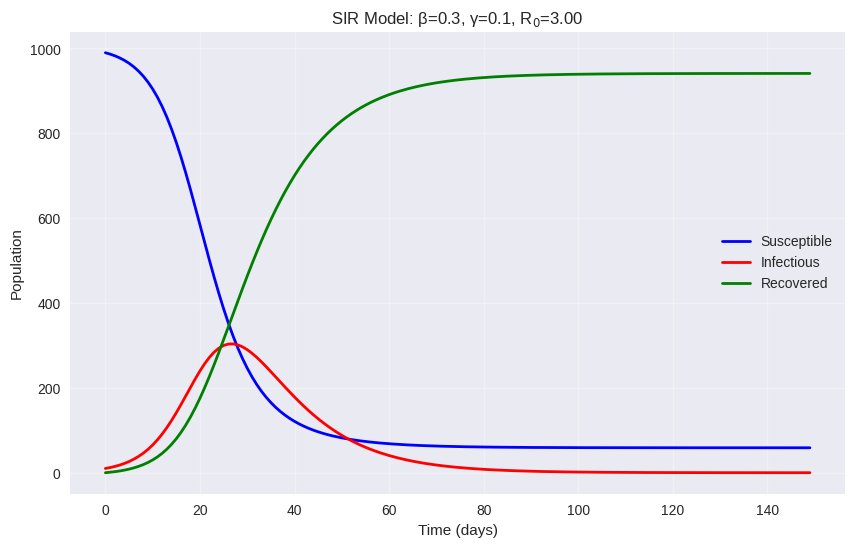


SIRD Model (with deaths):


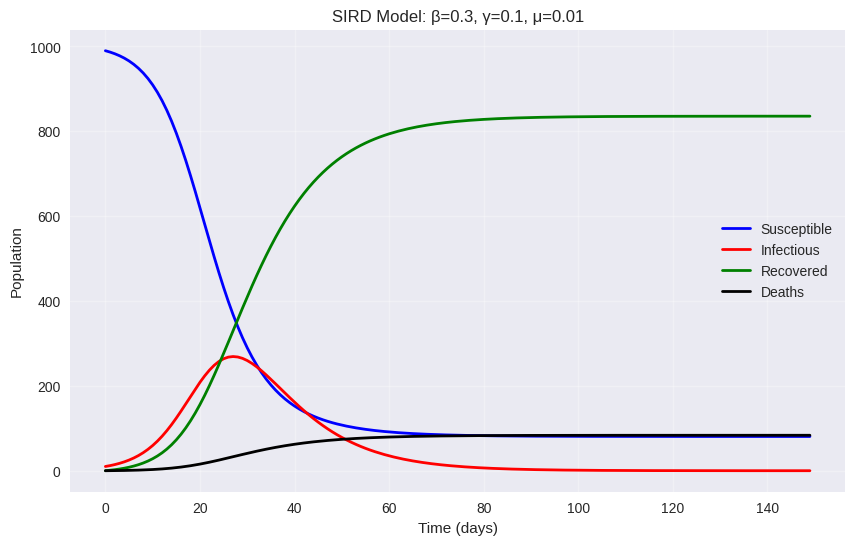


Comparison after 150 days:
SIR  - Recovered: 941
SIRD - Recovered: 836, Deaths: 84
Mortality rate: 9.1%


In [8]:
# 🟡 calculate number of recovered
beta, gamma, mu = 0.3, 0.1, 0.01

print("SIR Model (no deaths):")
t_sir, S_sir, I_sir, R_sir = run_sir_simulation(beta, gamma)

print("\nSIRD Model (with deaths):")
t_sird, S_sird, I_sird, R_sird, D_sird = run_sird_simulation(beta, gamma, mu)

# TODO: Calculate and compare final outcomes
print(f"\nComparison after {len(t_sir)} days:")
print(f"SIR  - Recovered: {R_sir[-1]:.0f}")
print(f"SIRD - Recovered: {R_sird[-1]:.0f}, Deaths: {D_sird[-1]:.0f}")

# TODO: Calculate mortality rate
mortality_rate = D_sird[-1] / (D_sird[-1] + R_sird[-1]) * 100
print(f"Mortality rate: {mortality_rate:.1f}%")


**Step 3.3: Interpretation**

🔴 **Questions** - TODO: Answer these questions

Try out different mortality rates and try to see the effect.

1. **How does mortality rate affect total deaths?**
   - More deaths happen in the population.

2. **Does mortality rate affect the epidemic curve shape?**
   - Yes, as there are less people infected due to deaths, they can affect the peak (lower and later).




---



## **Exercise 4: Real-World Application (25 minutes)**

**Step 4.1: Model a realistic scenario**

Now let's apply our SIRD model to a **COVID-19-inspired scenario** with realistic parameters. This will help us understand how our mathematical models translate to real-world epidemics.

We'll use estimated parameters based on early COVID-19 data:
- **Higher transmission rate** (β = 0.5) reflecting the highly contagious nature
- **Longer recovery time** (~10 days average)
- **Realistic mortality rate** (~2%)
- **Larger population** (10,000 people) to see clearer patterns

This scenario will show us the potential scale and timeline of an uncontrolled epidemic.

COVID-19 Scenario Parameters:
R0 = 5.00
Average recovery time: 10 days
Mortality rate: 2.0%


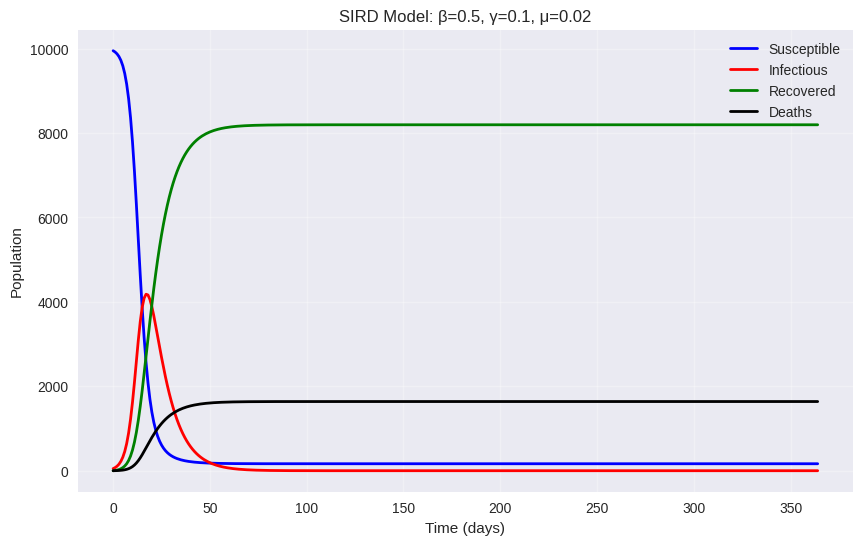


After 1 year:
Total infected: 9835 (98.3%)
Deaths: 1639 (16.39%)
Peak infections: 4181 on day 17


In [9]:
# 🟢 run this model to run a COVID-inspired model
def model_covid_scenario():
    # Estimated parameters (simplified)
    beta = 0.5      # High transmission
    gamma = 1/10    # ~10 day recovery period
    mu = 0.02       # ~2% mortality rate

    N = 10000       # Larger population
    I0 = 50         # Multiple initial cases
    days = 365      # One year

    print("COVID-19 Scenario Parameters:")
    print(f"R0 = {beta/gamma:.2f}")
    print(f"Average recovery time: {1/gamma:.0f} days")
    print(f"Mortality rate: {mu*100:.1f}%")

    t, S, I, R, D = run_sird_simulation(beta, gamma, mu, N, I0, days)

    print(f"\nAfter 1 year:")
    print(f"Total infected: {(R[-1] + D[-1]):.0f} ({(R[-1] + D[-1])/N*100:.1f}%)")
    print(f"Deaths: {D[-1]:.0f} ({D[-1]/N*100:.2f}%)")
    print(f"Peak infections: {max(I):.0f} on day {np.argmax(I)}")

    return t, S, I, R, D

# Run COVID scenario
covid_results = model_covid_scenario()

**Step 4.2: Intervention analysis**

Public health interventions like social distancing, mask mandates, or lockdowns primarily work by **reducing transmission rates**. Let's quantify how effective these interventions can be.

We'll compare two scenarios:
- **No intervention**: High transmission (β = 0.5)
- **With intervention**: Reduced transmission (β = 0.3) representing a 40% reduction

This analysis will help us calculate concrete metrics like **lives saved**, **peak reduction**, and **intervention effectiveness** - the kind of analysis that informs real policy decisions.

Scenario 1: No intervention


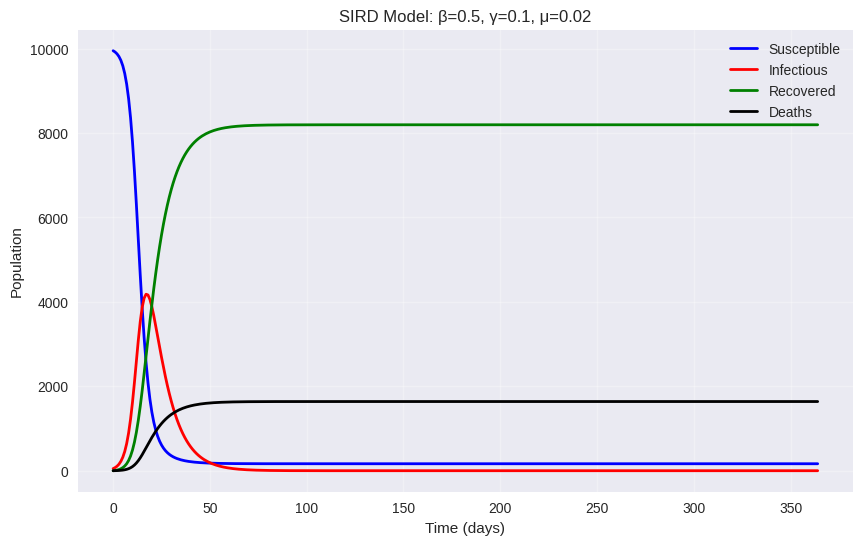


Scenario 2: With intervention


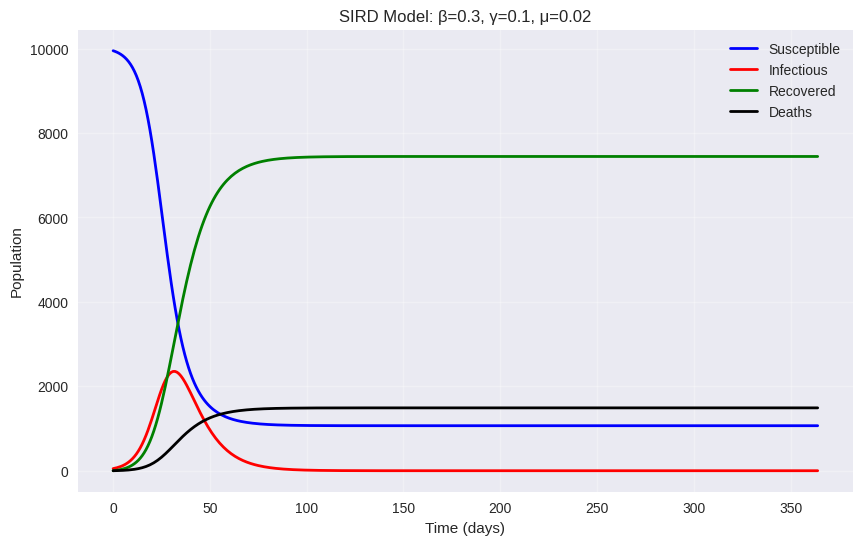

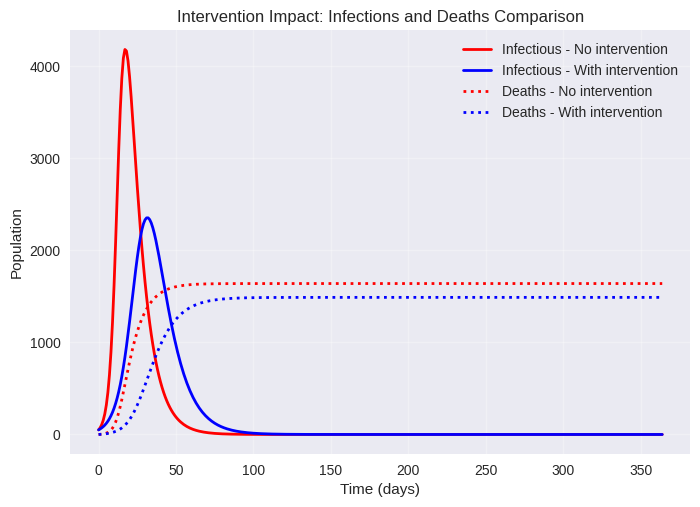


Intervention Impact:
Deaths prevented: 150
Peak reduction: 1829 fewer peak infections
Lives saved: 9.2% reduction in deaths
Peak delay: 15 days


In [10]:
# 🟢 investigate intervention effect
def compare_intervention():

    # Parameters
    gamma, mu = 1/10, 0.02
    N, I0, days = 10000, 50, 365

    beta_no_intervention = 0.5
    beta_with_intervention = 0.3 # 40% reduction in transmission

    print("Scenario 1: No intervention")
    t1, S1, I1, R1, D1 = run_sird_simulation(beta_no_intervention, gamma, mu, N, I0, days)

    print("\nScenario 2: With intervention")
    t2, S2, I2, R2, D2 = run_sird_simulation(beta_with_intervention, gamma, mu, N, I0, days)

    # Plot infectious populations
    plt.plot(t1, I1, 'r-', label='Infectious - No intervention', linewidth=2)
    plt.plot(t2, I2, 'b-', label='Infectious - With intervention', linewidth=2)

    # Plot deaths (cumulative)
    plt.plot(t1, D1, 'r:', label='Deaths - No intervention', linewidth=2)
    plt.plot(t2, D2, 'b:', label='Deaths - With intervention', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title('Intervention Impact: Infections and Deaths Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Summary comparison
    print(f"\nIntervention Impact:")
    print(f"Deaths prevented: {D1[-1] - D2[-1]:.0f}")
    print(f"Peak reduction: {max(I1) - max(I2):.0f} fewer peak infections")
    print(f"Lives saved: {((D1[-1] - D2[-1])/D1[-1])*100:.1f}% reduction in deaths")
    print(f"Peak delay: {np.argmax(I2) - np.argmax(I1)} days")

compare_intervention()

**Step 4.3: Interpretation**

🔴 **Questions** - TODO: Answer based on your COVID-19 scenario and intervention analysis:

1. **COVID-19 scenario interpretation:**
   - What percentage of the population gets infected in the uncontrolled scenario?
        - 98.3%
   - How does the timeline compare to what we observed in real COVID-19 outbreaks?
        - It happened much quicker in the model than in real life.

2. **Intervention effectiveness:**
   - How many lives were saved by the 40% transmission reduction?
        - 150
   - What was the percentage reduction in peak infections?
        - 1829
   - By how many days was the epidemic peak delayed?
        - 15

3. **Policy implications:**
   - If you were a public health official, what would you conclude about the value of interventions that reduce transmission by 40%?
        - that they are beneficial to society. Not only do they reduce deaths but also allow for lower and later peaks, this would help hospitals and healthcare workers by lowering workload at any given time.
   - What are the trade-offs between intervention strength and epidemic outcomes?
        - interventions can disrupt normal social life, and peoples work, lowering economy, however they serve to prevent deaths and infections.

4. **Model limitations:**
   - What aspects of real COVID-19 outbreaks does our model miss?
        - does not apply to people who might get infected again, as some did in the real world. Also it would be beneficial to record what age groups ar suseptible for deaths because those would need better prevention.
        



---

# Assignment: Recovery Rate Investigation

Using the **SIRD model** implemented above, this section investigates how changing the recovery rate, γ, changes epidemic outcomes. The assignment-specified basic reproduction number is calculated as **R₀ = β/γ**.


## Part 1: Parameter analysis function

The function below tests `gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]`, records the required epidemic metrics, returns them as a `pandas.DataFrame`, and plots all infectious curves on one publication-quality figure.


In [20]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    gamma_v = [0.05, 0.1, 0.15, 0.2, 0.25]
    t = np.linspace(0, simulation_days - 1, simulation_days)
    results = []

    fig, ax = plt.subplots(figsize=(10, 6))

    for gamma in gamma_v:
        # Initial SIRD
        y0 = [N - I0, I0, 0, 0]
        sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = sol.T

        #metrics
        peak_infected = np.max(I)
        peak_day = int(np.argmax(I))
        total_deaths = D[-1]
        R0 = beta / gamma

        results.append({
            'gamma': gamma,
            'R0': R0,
            'peak_infected': peak_infected,
            'peak_day': peak_day,
            'total_deaths': total_deaths
        })

        ax.plot(t, I, linewidth=2,
                label=f'γ={gamma:.2f} (R_0={R0:.2f})')

    # plot
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Infectious individuals')
    ax.set_title(
        f'Effect of Recovery Rate on Epidemic Curves '
        f'(β={beta}, μ={mu}, N={N})'
    )
    ax.legend(title='Recovery rate', frameon=True)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()

    #Convert data to panda Dataframe
    results_df = pd.DataFrame(
        results,
        columns=['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths']
    )

    # Formatting
    return results_df.round({
        'gamma': 2,
        'R0': 2,
        'peak_infected': 1,
        'total_deaths': 1
    })


## Part 2: Scenario comparison

### Scenario A — High Transmission
`beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200`

### Scenario B — Low Transmission
`beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200`


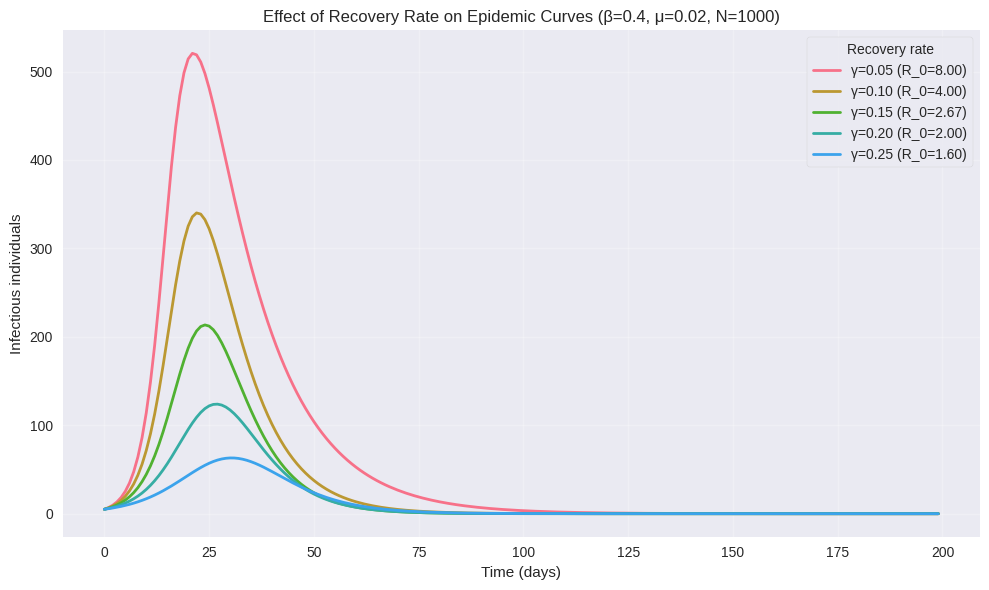

Scenario A - High Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.6,21,284.8
1,0.10,4.00,340.1,22,159.9
2,0.15,2.67,213.5,24,102.6
3,0.20,2.00,123.9,27,67.4
4,0.25,1.60,63.1,30,42.7


In [21]:
# Run Scenario A - High Transmission
scenario_A_results = analyze_recovery_rates(
    beta=0.4,
    mu=0.02,
    N=1000,
    I0=5,
    simulation_days=200
)

print("Scenario A - High Transmission")
display(scenario_A_results)


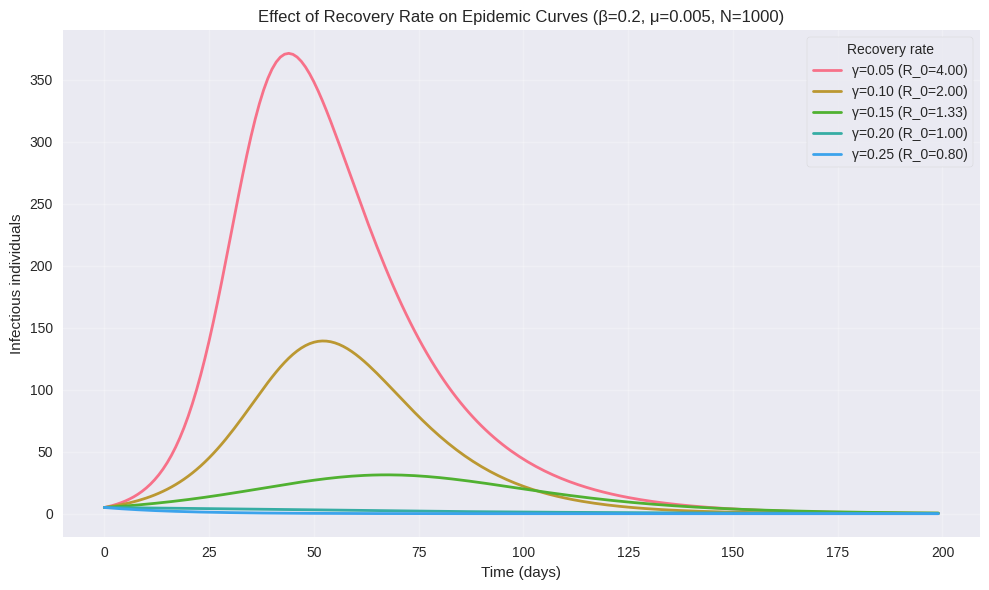

Scenario B - Low Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.4,44,88.2
1,0.10,2.00,139.3,52,36.7
2,0.15,1.33,31.3,67,13.6
3,0.20,1.00,5.0,0,1.8
4,0.25,0.80,5.0,0,0.4


In [22]:
# Run Scenario B - Low Transmission
scenario_B_results = analyze_recovery_rates(
    beta=0.2,
    mu=0.005,
    N=1000,
    I0=5,
    simulation_days=200
)

print("Scenario B - Low Transmission")
display(scenario_B_results)


### Comparative visualization

The plots below compare the two scenarios across recovery rates using two public-health outcomes: peak infectious population and final deaths.


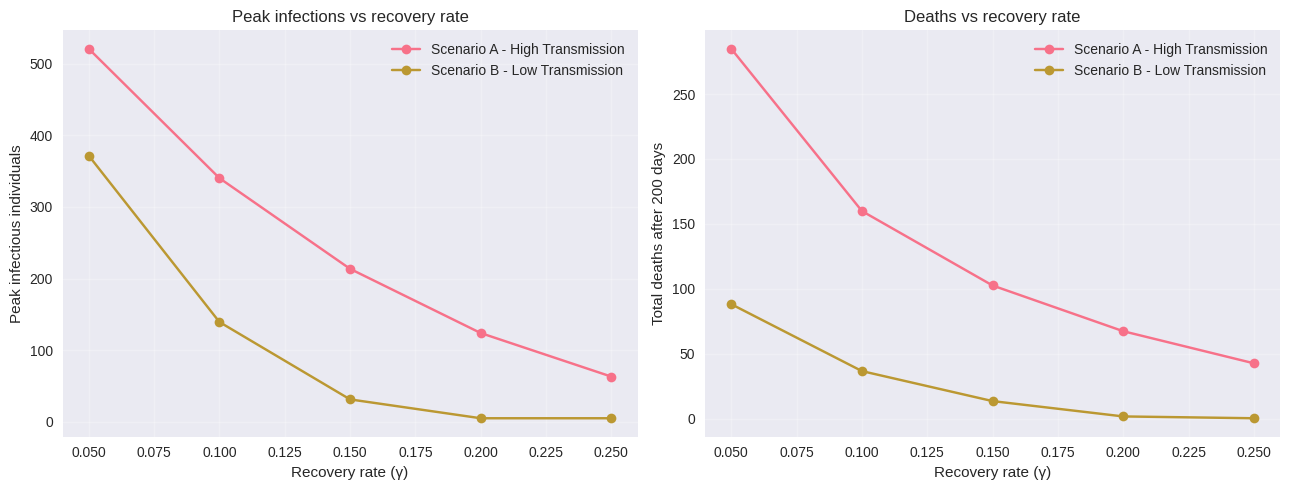

In [19]:
# side by side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plots
axes[0].plot(
    scenario_A_results['gamma'], scenario_A_results['peak_infected'],
    marker='o', label='Scenario A - High Transmission'
)
axes[0].plot(
    scenario_B_results['gamma'], scenario_B_results['peak_infected'],
    marker='o', label='Scenario B - Low Transmission'
)
axes[0].set_xlabel('Recovery rate (γ)')
axes[0].set_ylabel('Peak infectious individuals')
axes[0].set_title('Peak infections vs recovery rate')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(
    scenario_A_results['gamma'], scenario_A_results['total_deaths'],
    marker='o', label='Scenario A - High Transmission'
)
axes[1].plot(
    scenario_B_results['gamma'], scenario_B_results['total_deaths'],
    marker='o', label='Scenario B - Low Transmission'
)
axes[1].set_xlabel('Recovery rate (γ)')
axes[1].set_ylabel('Total deaths after 200 days')
axes[1].set_title('Deaths vs recovery rate')
axes[1].grid(True, alpha=0.25)
axes[1].legend()


fig.tight_layout()
plt.show()


### Scenario analysis

**Scenario A is worse for public health across all  recovery rates.**

It combines a higher transmission rate (`β=0.4` versus `0.2`) with a higher mortality rate (`μ=0.02` versus `0.005`). For example, at γ=0.10, Scenario A has R_0=4.00, a peak of about 340.1 infectious people on day 22, and about 159.9 deaths by day 200. Scenario B at the same recovery rate has R_0=2.00, a peak of about 139.3 infectious people on day 52, and about 36.7 deaths. Therefore Scenario A has a larger and earlier peak and many more deaths at the recovery rate. Increasing γ improves both scenarios because infectious individuals stop being infected faster. Meaning that there is less time for infected individuals to infect others.


## Part 3: Policy recommendations

### 3.1 Parameter impact analysis

How does increasing recovery rate affect peak infections, total deaths, and epidemic duration?

Increasing the recovery rate strongly reduces the impact of the epidemic. In **Scenario A**, raising γ from 0.05 to 0.25 reduces the peak infectious population from about 520.6 to 63.1 and reduces total deaths by about 242. The peak also moves from day 21 to day 30, meaning that faster recovery both flattens the  curve and delays the peak.



### 3.2 Intervention analysis

In [15]:
# Quantify a 50% increase in recovery rate for Scenario A.
# Baseline gamma = 0.10, so a 50% increase gives gamma = 0.15.
baseline_gamma = 0.10
improved_gamma = 0.15

baseline = scenario_A_results.loc[np.isclose(scenario_A_results['gamma'], baseline_gamma)].iloc[0]
improved = scenario_A_results.loc[np.isclose(scenario_A_results['gamma'], improved_gamma)].iloc[0]

# calculations from the SIRD
deaths_prevented = baseline['total_deaths'] - improved['total_deaths']
percent_death_reduction = deaths_prevented / baseline['total_deaths'] * 100
peak_reduction = baseline['peak_infected'] - improved['peak_infected']
percent_peak_reduction = peak_reduction / baseline['peak_infected'] * 100


print(f"Baseline γ: {baseline_gamma:.2f}")
print(f"50% higher γ: {improved_gamma:.2f}")
print(f"Deaths at baseline: {baseline['total_deaths']:.1f}")
print(f"Deaths after intervention: {improved['total_deaths']:.1f}")
print(f"Deaths prevented: {deaths_prevented:.1f}")
print(f"Percentage reduction in deaths: {percent_death_reduction:.1f}%")
print(f"Peak infections reduced by: {peak_reduction:.1f} ({percent_peak_reduction:.1f}%)")


Baseline γ: 0.10
50% higher γ: 0.15
Deaths at baseline: 159.9
Deaths after intervention: 102.6
Deaths prevented: 57.3
Percentage reduction in deaths: 35.8%
Peak infections reduced by: 126.6 (37.2%)




Using Scenario A with γ=0.10 as the baseline, a 50% improvement in recovery rate gives:

- Baseline recovery rate: γ = 0.10
- Improved recovery rate: γ = 0.15
- Baseline deaths: 159.9
- Deaths with improved recovery: 102.6
- Deaths prevented: 159.9 − 102.6 = 57.3
- Percentage reduction: 57.3 / 159.9 × 100 ≈ 35.8%

The model therefore predicts that this 50% increase in γ would prevent around 57 deaths per  1,000 people in  Scenario A over  200 days using the simulation. Peak infections also fall from around 340.1 to 213.5, a reduction of around 37.2%.


### 3.3 Real-world application


Antiviral medication is a medical intervention and common treatment used to speed up recovery rates. They work by inhibiting a virus’s ability to replicate and can therefore shorten a patient's time to recover. An example of an antiviral medication would be Sofosbuvir, Sofosbuvir has a broad antiviral spectrum against many species of the Flaviviridae and Togaviridae families (including yellow fever, Zika, dengue, chikungunya, and hepatitis C viruses). According to the pooled meta-analysis of four randomized controlled trials (RCTs), a Sofosbuvir based regimen significantly increased clinical recovery rates by 20% compared to standard care or alternative treatment.

Rate Ratio (RR): 1.20 (95% CI: 1.04–1.38).

In individual trials, it also demonstrated:

Lower mortality: RR 0.31 (95% CI: 0.12–0.78).

Fewer ICU admissions: RR 0.33 (95% CI: 0.15–0.72).

Shorter hospital stays: Reduced from 8 to 6 days (p = 0.029) in moderate/severe COVID-19, and from 9 to 5 days (p < 0.01) compared to ribavirin in severe cases.

Data from:
Lai, C.-C., Chao, C.-M., & Hsueh, P.-R. (2021). Clinical efficacy of antiviral agents against coronavirus disease 2019: A systematic review of randomized controlled trials. Journal of Microbiology, Immunology and Infection, 54(5), 767–775. https://doi.org/10.1016/j.jmii.2021.05.011










